In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')


In [47]:
df = pd.read_csv('insurance.csv')

In [48]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [50]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [51]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

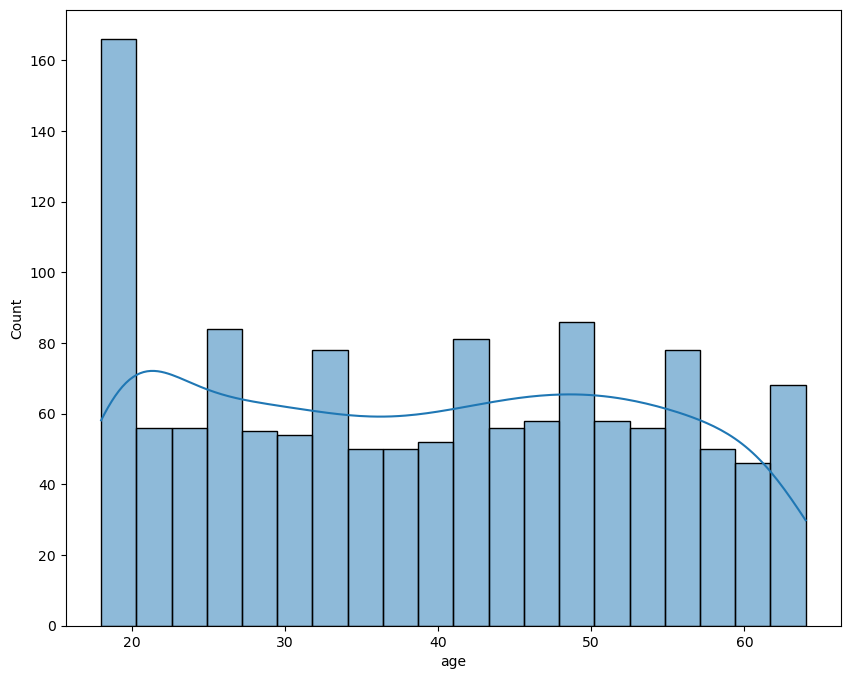

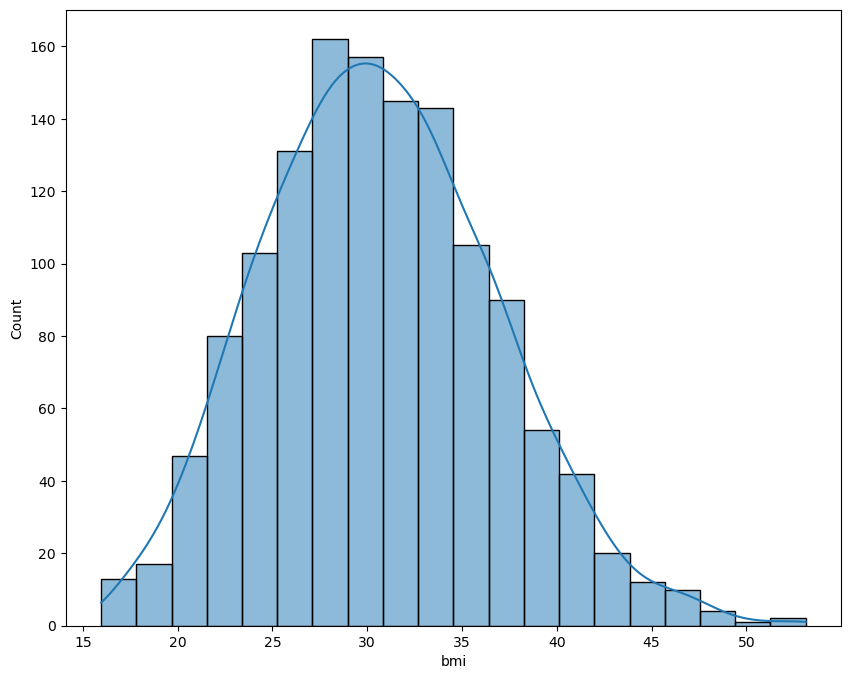

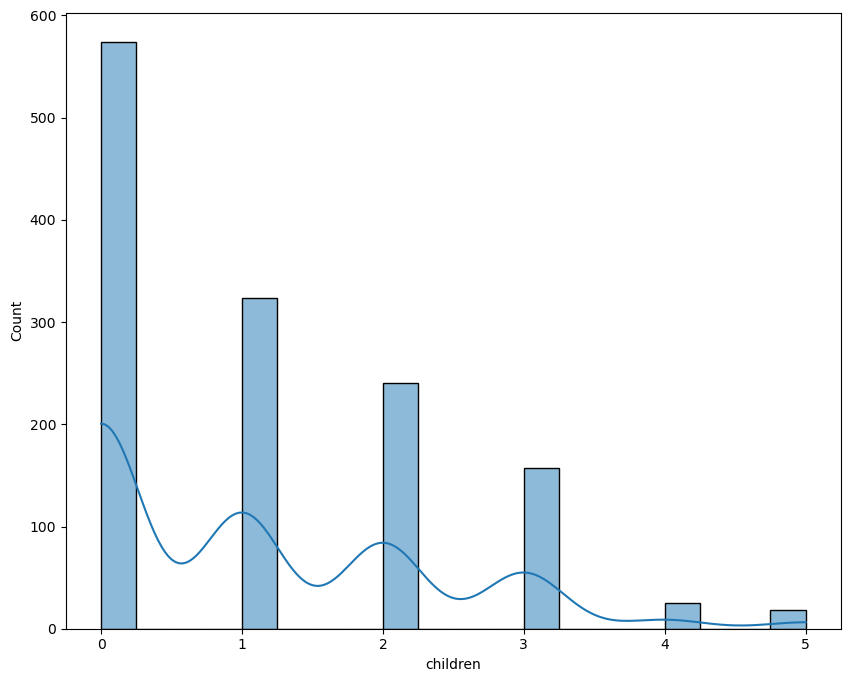

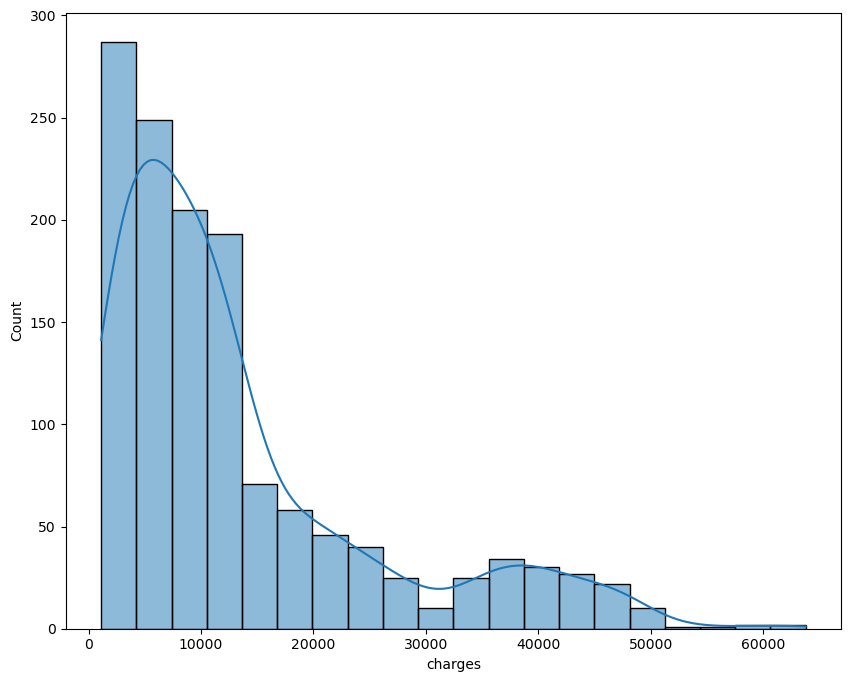

In [52]:
numeric_cols = [ "age",  "bmi", "children","charges" ]
for col in numeric_cols:
    plt.figure(figsize=(10, 8))
    sns.histplot(df[col], kde=True, bins=20)
    


<Axes: xlabel='sex', ylabel='count'>

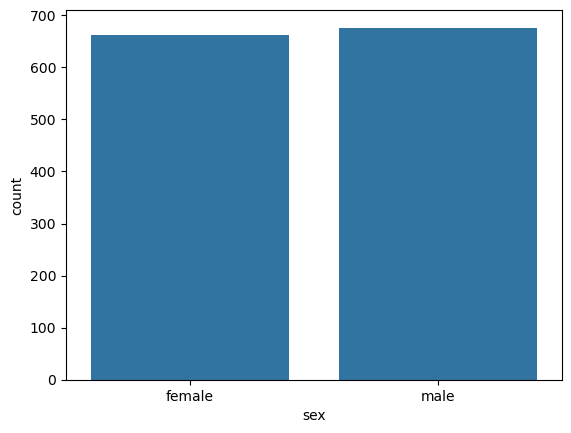

In [53]:
sns.countplot(x = df["sex"])

<Axes: xlabel='children', ylabel='count'>

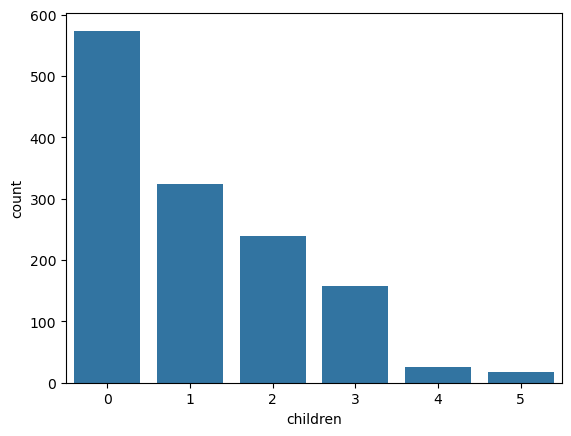

In [54]:
sns.countplot(x = df["children"])

<Axes: xlabel='smoker', ylabel='count'>

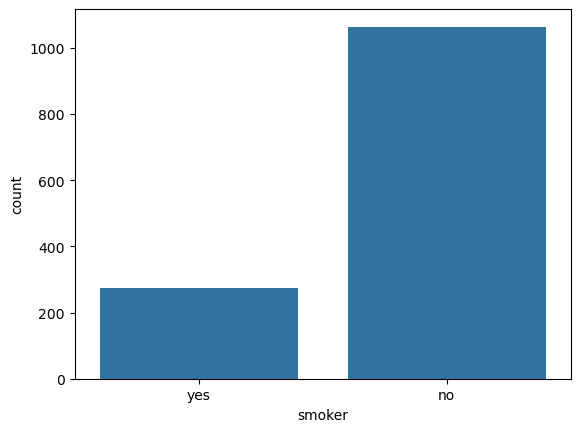

In [55]:
sns.countplot(x = df["smoker"])

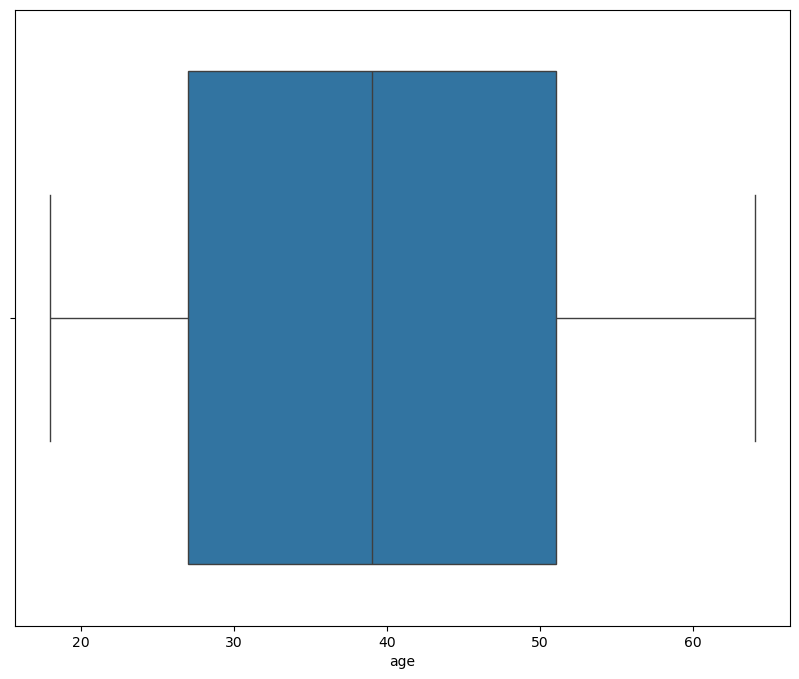

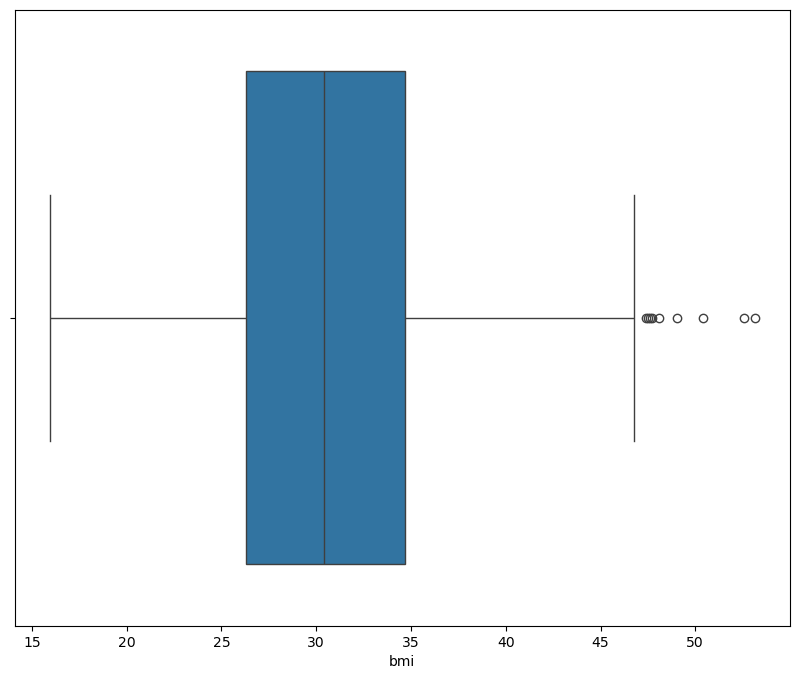

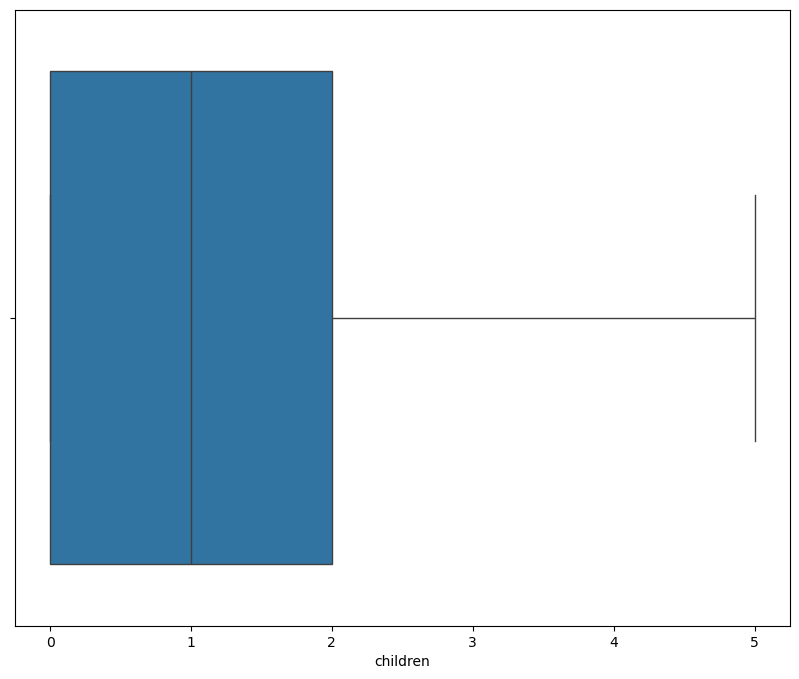

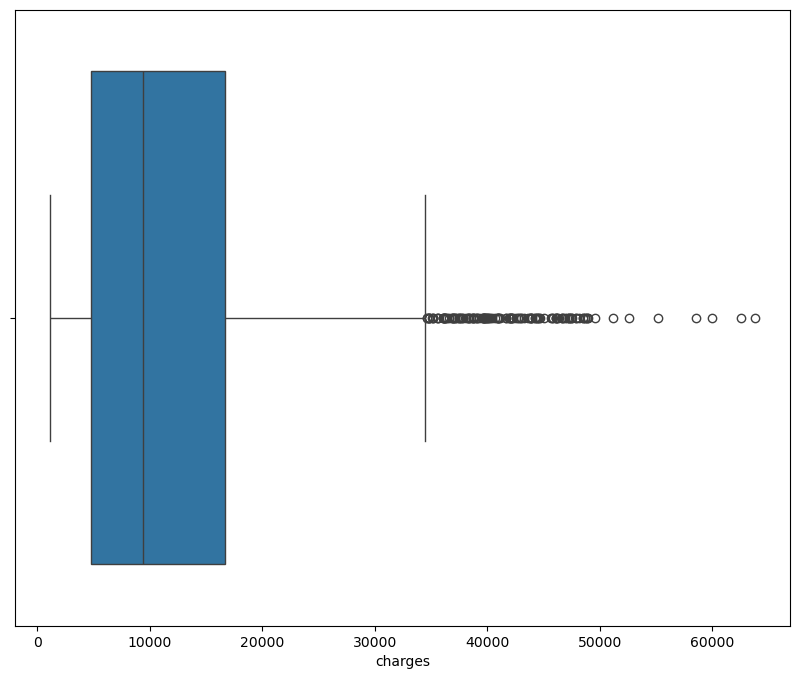

In [56]:
for col in numeric_cols:
    plt.figure(figsize=(10, 8))
    sns.boxplot( x = df[col])

<Axes: >

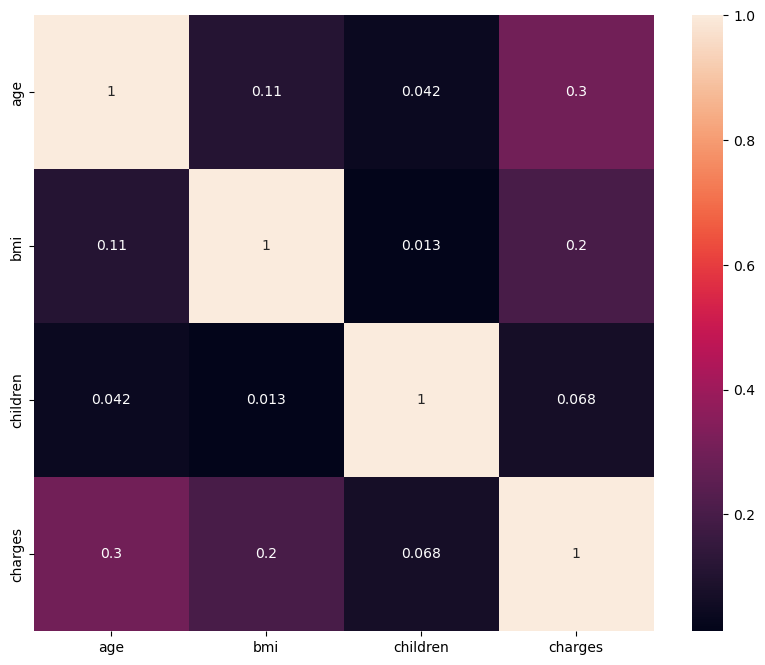

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data cleaning and Preprocessing 

In [58]:
df_cleaned = df.copy()

In [59]:
df_cleaned.shape

(1338, 7)

In [60]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [61]:
df_cleaned.drop_duplicates(inplace= True)

In [62]:
df_cleaned.shape

(1337, 7)

In [63]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [64]:
df_cleaned["sex"].value_counts()


sex
male      675
female    662
Name: count, dtype: int64

In [65]:
df_cleaned["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [66]:
df_cleaned["sex"] = df_cleaned["sex"].map({"male": 0, "female": 1})
df_cleaned["smoker"] = df_cleaned["smoker"].map({"no": 0, "yes": 1})

In [67]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [68]:
df_cleaned.rename(
    columns={
        'sex': 'is_female',
        'smoker': "is_smoker"
    },
    inplace=True
)

In [69]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [70]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [71]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# Feature engeneering and extraction 

In [72]:
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels= ['Underweight', 'Normal', 'Overweight', 'Obese']
)


In [73]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Normal
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight


In [74]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [75]:
df_cleaned = df_cleaned.astype(int)

In [76]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [77]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [79]:
cols_to_scale = ['age', 'bmi', 'children']

In [80]:
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

In [81]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [82]:
corr_with_charges = df_cleaned.corr(method="pearson")["charges"]

In [83]:
corr_with_charges.sort_values()

bmi_category_Overweight   -0.118280
bmi_category_Normal       -0.105656
is_female                 -0.058046
region_southwest          -0.043637
region_northwest          -0.038695
children                   0.067390
region_southeast           0.073577
bmi                        0.196236
bmi_category_Obese         0.197660
age                        0.298309
is_smoker                  0.787234
charges                    1.000000
Name: charges, dtype: float64

In [89]:
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

In [90]:
cat_features = [
    'age', 'is_female', 'bmi', 'children', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

X = df_cleaned[cat_features]
y = df_cleaned['charges_bin']

In [92]:
from scipy.stats import chi2_contingency

In [93]:
alpha = 0.05
chi2_results = {}

for col in cat_features:
    # Create contingency table
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    
    # Apply chi-square test
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    
    # Decision
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    # Store results
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

In [94]:
chi2_df = pd.DataFrame(chi2_results).T

# Sort by p-value
chi2_df = chi2_df.sort_values(by='p_value')

In [95]:
chi2_df

,chi2_statistic,p_value,Decision
age,1509.13025,0.0,Reject Null (Keep Feature)
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi,144.758888,0.017278,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)


In [96]:
df_final = df_cleaned[[
    'age', 'is_female', 'bmi', 'is_smoker', 'children',
    'region_southeast',
    'bmi_category_Obese'
]]